# 뇌출혈 조기 진단을 위한 세그멘테이션 모델 개발

프로젝트 번호: 3

# 목차

1. 프로젝트 개요
	1. 프로젝트 연구 배경
    1. Gated Axial-Attention Layer
    1. Local-Global Training (LoGo)
	1. 기대 효과
1. 실습 환경 설정
	1. 엘리스 클라우드 가입
	1. 인스턴스 생성
	1. 인스턴스 삭제
    1. 인스턴스 SSH 접속
    1. 버전 확인
	1. 코드 업로드
    1. 패키지 설치
1. 데이터셋 준비
    1. 데이터셋 소개
    1. 데이터셋 다운로드
    1. 데이터셋 다운로드 확인
    1. 데이터셋 시각화
1. 모델 구축
    1. 파라미터 설정
    1. 필요한 모듈 로드
    1. 데이터셋 로드
    1. 데이터셋 전처리
	1. 데이터셋 분할
    1. 학습 완료 콜백 함수
    1. 모델 생성 함수
    1. 모델 학습 함수
    1. 모델 평가 함수
1. 모델 학습
	1. 주요 변수 설명
	1. 모델 학습 관련 코드 블록
	1. 모델 검증 관련 코드 블록
	1. 코드 실행
1. 모델 실험 결과
	1. 데이터 시각화 준비
	1. 손실 그래프
	1. 정확도 그래프
	1. 그래프 표시
    1. 결과 분석
1. 결론
	1. 주요 업적
	1. 현장 실무에 유용할 주요 핵심 정리
	1. 기존 연구와의 차별점
	1. 기술적 한계
	1. 향후 연구 과제


# 프로젝트 개요

예상 모델 학습 소요시간: 45분\
컴퓨팅 성능 요구: 낮음\
논문: Valanarasu, J. M. J., Oza, P., Hacihaliloglu, I., & Patel, V. M. (2021). Medical transformer: Gated axial-attention for medical image segmentation. In International Conference on Medical Image Computing and Computer-Assisted Intervention (MICCAI) (pp. 36–46). Springer.\
소스코드 원본 주소: (https://github.com/jeya-maria-jose/Medical-Transformer)

## 프로젝트 연구 배경

- 의료 영상 분할은 진단, 수술 계획, 병변 분석 등 다양한 임상적 응용에서 핵심적인 역할
- 병리 슬라이드, CT, MRI 영상에서 특정 구조(예: 종양, 세포핵 등)를 정확히 분할하는 것은 전문가 수준의 해상도와 문맥적 이해를 동시에 요구하는 어려운 과제
- 전통적인 분할 모델인 U-Net과 그 변형들은 합성곱 신경망(CNN) 기반으로 동작
- CNN은 지역적 수용 영역을 바탕으로 하기 때문에, 장거리 문맥 정보를 포착하는 데 한계가 있음
- 세포핵처럼 국소적인 경계 정보와 전체 조직 구조가 동시에 중요한 경우, 기존 모델은 두 가지 모두를 적절히 처리하기 어려움


`기술 동향`
- CNN 기반 의료 영상 분할 모델
    - Ronneberger, O., Fischer, P., & Brox, T. (2015). U-net: Convolutional networks for biomedical image segmentation. In International Conference on Medical image computing and computer-assisted intervention (pp. 234–241). Springer
    - Zhou, Z., Siddiquee, M. M. R., Tajbakhsh, N., & Liang, J. (2018). Unet++: A nested u-net architecture for medical image segmentation. In DLMIA/ML-CDS@MICCAI
- Transformer 기반 시각 모델의 적용 시도
    - Dosovitskiy, A., Beyer, L., Kolesnikov, A., et al. (2021). An image is worth 16x16 words: Transformers for image recognition at scale. In ICLR.
    - Chen, J., Lu, Y., Yu, Q., et al. (2021). Transunet: Transformers make strong encoders for medical image segmentation. arXiv preprint arXiv:2102.04306.

## Architecture

<figure>
    <img src="https://github.com/jeya-maria-jose/Medical-Transformer/blob/main/img/medt1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## Gated Axial-Attention Layer

`Gated Axial-Attention Layer`
- 기존 `2D self-attention`의 높은 계산 복잡도를 줄이기 위해, `Axial-Attention` 구조를 사용, 2D attention을 `row-wise(H 방향) attention`와 `column-wise(W 방향) attention`으로 분리함
- 기존의 `Axial-Attention`은 각 방향에 `positional encoding`을 추가하여 `spatial relationship`을 반영했지만, 이는 정보 손실이나 비효율성을 유발할 수 있음
- 이를 보완하기 위해 `positional encoding`을 단순히 더하는 방식 대신, `gating mechanism`(positional encoding의 비중을 학습 가능한 게이트로 조절)을 적용함
- 수직 방향(H)에 대해 attention을 수행한 후, positional encoding을 gating하여 합산하고,
동일하게 수평 방향(W)에 대해서도 수행함
- `gated axial-attention layer`는 spatial 방향의 중요한 정보를 동적으로 조절하면서도, 계산량을 유지하며 효율적인 attention을 가능하게 함

## Local-Global Training (LoGo)

`Local-Global Training (LoGo)`
- 전체 네트워크를 두 개의 병렬 `encoder branch`로 구성
- `Global branch`: 전체 이미지를 입력받아 `global context`를 학습
- `Local branch`: 입력 이미지를 여러 개의 패치로 나눈 뒤 각 패치를 처리
- `global branch`는 `gated axial attention`을, `local branch`는 `positional encoding` 없이 `axial attention`을 사용
- 두 branch의 출력을 channel-wise로 concat한 뒤 convolution layer로 fusion함
- 이후 fused feature는 decoder에 전달되어 segmentation 결과로 출력됨
- 각 branch가 서로 다른 시야(field-of-view)를 가지므로, local branch는 fine-grained details, global branch는 전체적인 구조를 담당


제안 기술 기대 효과

`Gated Axial-Attention Layer`
- 기존 2D self-attention의 계산량을 크게 줄이면서도, 수직/수평 방향의 공간적 의존성을 효과적으로 포착할 수 있음
- 고해상도 의료 영상에서도 계산량을 줄이면서, 더 정밀한 경계 인식과 구조적 패턴 학습을 가능하게 함

`Local-Global Training (LoGo) Strategy`
- 하나의 이미지를 두 가지 경로(global, local)로 병렬 학습시켜서 서로 다른 수준의 정보 학습
- 제한된 데이터에서도 전체 구조와 미세 구조를 동시에 반영할 수 있어, 성능과 일반화 측면 모두에서 강인한 segmentation 결과를 얻을 수 있음

# 실습 환경 설정

## 엘리스 클라우드 가입

1. 엘리스 클라우드 가입 시 사용할 이메일 주소로 초대장이 보내짐
1. 이메일을 열어 초대장 메일을 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/mail1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. "`학습지 가기`"를 클릭하여 로그인 화면으로 이동

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/mail2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 메일에 나와있는 이메일 아이디와 임시포스트를 입력하여 로그인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 사용할 비밀번호를 입력하고 필수 동의사항에 동의 후 회원가입 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 회원가입 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 생성

1. 왼쪽 상단의 LXP를 클릭한 뒤 클라우드를 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 내 인스턴스 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 인스턴스 생성을 클릭하여 생성 화면으로 이동

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 인스턴스 유형으로 G-NAHP-80(A100 80GB PCle)을 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 인스턴스 이름 작성 후 실행 환경은 Jupyter 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 스토리지 옵션으로 `128`GB 선택\
주의: 본 프로젝트의 용량이 `6`GB이므로 프로젝트 용량보다 더 큰 용량 선택
7. 이후 인스턴스 생성을 클릭해 생성을 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

8. 이제 생성된 인스턴스에서 실습을 진행함
1. 이후 내 인스턴스 페이지로 돌아가기 위해 왼쪽 상단의 내 인스턴스 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 삭제

- 인스턴스 화면에 없어도 인스턴스는 계속 실행되고 있으므로 삭제 필요
- 사용이 끝난 경우 반드시 ‘종료’ 버튼을 눌러 실행을 중지해야 함\
(단, 종료는 인스턴스에 여전히 필요한 데이터나 설정이 남아 있는 경우에만 사용)
- 인스턴스를 더 이상 사용할 일이 없다면, ‘삭제’를 통해 완전히 제거해야함
- 삭제는 반드시 인스턴스가 종료된 상태에서만 가능하며, 한 번 삭제하면 복구할 수 없음

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 접속(SSH)

### PEM 다운로드

> 주의: 한번 다운로드 받은 PEM 파일은 잘 보관해야 함\
> 재 발급 받은 경우 키 값이 달라지므로 재 발급 받은 파일로는 기존의 인스턴스에 접속 불가함\
> SSH 접속은 실습 환경에 필요한 모듈을 다운받는 등에 사용함

1. SSH 접속을 위해서는 비밀키 파일(PEM 파일) 필요\
비밀키 발급하기 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. SSH 접속을 위해서는 비밀키 파일(PEM 파일) 필요\
PEM 파일 다운로드하기를 클릭하여 PEM 파일 저장

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Command Prompt(혹은 Powershell) 실행

1. 윈도우(<span style="font-family: 'Wingdings';">&#xFF;</span>)  + R 키를 누르기
1. cmd 입력 (또는 powershell 입력)
1. Enter키 눌러서 Command Prompt 실행

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. "`cd [PEM파일 폴더 경로]`" 명령어를 사용하여 PEM 파일이 있는 위치로 이동\
예시: `cd %userprofile%\Downloads`\
(PEM 저장 위치 예시: 다운로드 폴더, 바탕화면, USB 등...)

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### SSH 접속 명령어

1. 내 인스턴스 페이지에서 다른 SSH 클라이언트 사용 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 빠른 연결칸의 명령어를 복사

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 복사한 명령어를 앞서 실행한 powershell 또는 cmd에 붙여넣기

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. SSH 접속 완료, SSH 접속 창은 계속 사용 되므로 창을 닫지 않음

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 버전 확인

### 파이썬 버전 확인

주피터 노트북에서 아래 명령어를 입력하여 확인하며 `엘리스 클라우드`의 주피터 노트북에 접속하여 입력함
> Tip: 파이썬 버전에 따라 텐서플로우 설치 가능 버전이 달라짐

1. 내 인스턴스에서 연결을 클릭하여 Jupyter notebook에 접속

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 우측 상단 `new` 버튼 클릭후 `Python 3(ipykernel)` 버튼 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 코드를 작성하여 파이썬 버전을 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

In [1]:
import sys
print('Python version', sys.version)

Python version 3.10.13 (main, Nov 21 2023, 07:43:03) [GCC 11.3.0]


## 코드 업로드

### 주피터 노트북 웹 페이지에서 바로 업로드 하기

1. 내 인스턴스에서 연결을 클릭하여 Jupyter notebook에 접속

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 우측 상단에 있는 `Upload` 버튼 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 열기 대화창이 뜨면 다운 받은 주피터노트북 교육자료 파일(*.jpynb) 선택 후 `열기(O)` 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 파란색 `Upload` 버튼을 클릭하여 엘리스 클라우드 서버로 파일 업로드

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 업로드한 교육자료 파일을 클릭하여 파일 열기

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 강사의 지도에 따라 교육 자료를 활용

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 패키지 설치

### Miniconda 설치

> 원할하게 다양한 실습환경을 구축하기 위해 Miniconda의 가상환경을 생성하여 실습을 진행

SSH접속 후 아래의 명령어를 순차적으로 실행
- wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
- bash Miniconda3-latest-Linux-x86_64.sh
- source ~/.bashrc

1. 명령어 작성 예시

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. Please, press Enter to continue가 나오면 Enter 키를 누른 후 Page Down 키를 눌러 가장 아래로 내려감

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Do you accept the license terms? [yes/no]가 나오며 yes 입력 후 Enter 키를 눌러 넘어감

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2-1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. You can undo this by running 'conda init --reverse $SHELL'? [yes/no]가 나오면 yes를 입력하여 Miniconda 설치 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2-2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. Miniconda 설치 완료\
source ~/.bashrc 를 입력하여 변경 사항을 적용

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Conda 가상환경 생성 및 활성화

1. SSH에 가상환경 생성 명령어 작성
- conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
- conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
- conda create -n medt python=3.8 torchvision=0.11.1 cudatoolkit=11.3 -c pytorch -y

> conda create -n `가상환경 이름` python=`파이썬 버전` ...기타 패키지 한번에 다운로드

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv.png?raw=true" width="900">
    <figcaption>가상환경 생성 명령어 작성 예시</figcaption>
</figure>

2. 가상 환경 실행
- conda activate medt
> conda activate `가상환경 이름`

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. pip 업데이트
- pip install --upgrade pip setuptools wheel

### Jupyter Notebook과 가상환경 연동

1. ipykernel 설치
- pip install ipykernel

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. Jupyter Notebook에서 이 가상환경을 선택 가능한 커널로 등록
- python -m ipykernel install --user --name=medt --display-name "Medical Transformer"
- python -m ipykernel install --user --name=`가상환경 이름` --display-name "`Jupyter에서 보여지는 이름`"

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Jupyter Notebook에서 해당 커널로 notebook 생성 가능

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 기존에 생성된 notebook에서 커널 변경 가능

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv6.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. python 버전이 정상적으로 변경 되었는지 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv7.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

In [1]:
import sys
print('Python version', sys.version)

Python version 3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]


### 필요한 라이브러리

필요한 라이브러리 설치는 SSH 환경에서 실행하도록 권장합니다.

`필요 라이브러리 설치 명령어`

가상환경이 활성화된 상태의 SSH에 입력, --verbose로 세부 다운로드 진행 표시.
- pip install nibabel==3.1.0 nipype==1.5.0 pydicom==2.0.0 pynrrd==0.4.2 pillow==10.4.0 tqdm==4.67.1 matplotlib==3.3.2 opencv-python==4.12.0.88 pandas==2.0.3 scikit-learn==0.23.2 pydot==1.4.1 pydotplus==2.0.2 natsort==7.0.1 simplejson==3.17.0 tensorboardX==2.6.2.2 --verbose

### GPU 확인

NVIDIA 드라이버 확인

In [2]:
!nvidia-smi

Fri Sep 26 17:17:16 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          On  | 00000000:65:00.0 Off |                   On |
| N/A   22C    P0              41W / 300W |                  N/A |     N/A      Default |
|                                         |                      |              Enabled |
+-----------------------------------------+----------------------+--

CUDA 버전 확인

In [3]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


CUDA 지원 확인
- 정상적인 경우 CUDA 사용 가능 : True 로 표시됩니다.
- 비정상적인 경우 CUDA 사용 가능 : False 로 표시됩니다.

In [4]:
# 1. 환경 설정 및 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# GPU 확인
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU를 사용할 수 없어 CPU를 사용합니다.")

print(f"PyTorch 버전: {torch.__version__}")

/home/elicer/miniconda3/envs/medt/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA 사용 가능: True
GPU 이름: NVIDIA A100 80GB PCIe MIG 3g.40gb
PyTorch 버전: 1.10.0


### 패키지 버전 및 설치 확인

`주피터 노트북 환경에서 패키지 설치 여부 및 버전 확인`

In [5]:
import matplotlib
print('matplotlib version', matplotlib.__version__)

matplotlib version 3.3.2


`Linux 환경에서 패키지 설치 여부 및 버전 확인(SSH 접속 필요)`
- pip list | grep `패키지_이름`
- conda list | grep `패키지_이름`

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/VersionCheck.png?raw=true" width="900">
    <figcaption>명령어 작성 예시</figcaption>
</figure>

> Tip: Windows는 grep 명령어 대신 findstr 명령어를 사용합니다.\
> %pip list | findstr `패키지_이름`\
> %conda list | findstr `패키지_이름`

---
# 데이터셋 준비

## 데이터셋 소개

'Brain Anatomy US dataset'
- 뇌출혈 조기 진단을 위한 초음파 데이터셋
- 환자 개인정보 문제로 비공개 조치되어, 아래 MoNuSeg 데이터셋 사용

`MoNuSeg`
- 다양한 기관의 종양 환자 조직 이미지를 활용하여 핵(nuclei) 분할을 위한 벤치마크를 제공하는 데이터셋
- 2018년 MICCAI 학회의 공식 위성 행사로 개최된 MoNuSeg 챌린지를 통해 소개되었으며, 이 챌린지의 목표는 다양한 기관과 환자에서 얻은 H&E 염색 조직 이미지에서 일반화 가능한 핵 분할 기술을 개발하는 것
<figure>
    <img src="https://www.researchgate.net/publication/363589671/figure/fig2/AS:11431281084688966@1663333020574/Sample-images-of-datasets-for-nuclei-detection-First-column-D1-MoNuSeg-18-second.ppm" width="900"/>
    <figcaption>그림 1: MoNuSeg 데이터셋의 샘플 이미지<br>출처: https://www.researchgate.net/figure/Sample-images-of-datasets-for-nuclei-detection-First-column-D1-MoNuSeg-18-second_fig2_363589671</figcaption>
</figure>

## 데이터셋 다운로드

루트 디렉토리로 이동

In [6]:
%cd /home/elicer

/home/elicer


아래 두 방식중 1가지를 선택하여 사용해주십시오.

데이터셋을 다운로드 하는 코드 (명령어 사용)

- Training과 Test를 위한 파일이 분리되어 제공
- Google drive 파일을 다운로드하기 위해 gdown 설치 후 진행
- gdown 오류가 발생하거나, 많은 시간이 소요되는 경우, 다음셀의 직접 업로드 방식 사용

In [7]:
!pip install gdown
!gdown --id 1JZN9Jq9km0rZNiYNEukE_8f0CsSK3Pe4 -O MoNuSegTrainingData.zip
!gdown --id 1NKkSQ5T0ZNQ8aUhh0a8Dt2YKYCQXIViw -O MoNuSegTestData.zip
!unzip -o MoNuSegTrainingData.zip
!unzip -o MoNuSegTestData.zip

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.1/105.1 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.4/152.4 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.8/129.8 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 16.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
/home/elicer/.local/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You 

직접 업로드
- TA가 제공하는 링크를 통해 다운받은 압축파일 두개를 루트 디렉토리에 업로드하고 진행

In [27]:
!unzip -o MoNuSegTrainingData.zip
!unzip -o MoNuSegTestData.zip

Archive:  MoNuSegTrainingData.zip
  inflating: MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-21-5784-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-21-5786-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-38-6178-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-49-4488-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-50-5931-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-A7-A13E-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-A7-A13F-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-AR-A1AK-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-AR-A1AS-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-AY-A8YK-01A-01-TS1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-B0-5698-01Z-00-DX1.xml  
  inflating: MoNuSegTrainingData/Annotations/TCGA-B0-5710-01Z-00-D

## 데이터셋 확인

데이터셋이 지정된 경로에 제대로 압축 해제 되었는지 확인

In [8]:
import os
print("TrainingData 폴더:", os.listdir("MoNuSegTrainingData"))
print("TestData 폴더:", os.listdir("MoNuSegTestData"))

TrainingData 폴더: ['Annotations', 'Tissue Images']
TestData 폴더: ['TCGA-2Z-A9J9-01A-01-TS1.tif', 'TCGA-2Z-A9J9-01A-01-TS1.xml', 'TCGA-44-2665-01B-06-BS6.tif', 'TCGA-44-2665-01B-06-BS6.xml', 'TCGA-69-7764-01A-01-TS1.tif', 'TCGA-69-7764-01A-01-TS1.xml', 'TCGA-A6-6782-01A-01-BS1.tif', 'TCGA-A6-6782-01A-01-BS1.xml', 'TCGA-AC-A2FO-01A-01-TS1.tif', 'TCGA-AC-A2FO-01A-01-TS1.xml', 'TCGA-AO-A0J2-01A-01-BSA.tif', 'TCGA-AO-A0J2-01A-01-BSA.xml', 'TCGA-CU-A0YN-01A-02-BSB.tif', 'TCGA-CU-A0YN-01A-02-BSB.xml', 'TCGA-EJ-A46H-01A-03-TSC.tif', 'TCGA-EJ-A46H-01A-03-TSC.xml', 'TCGA-FG-A4MU-01B-01-TS1.tif', 'TCGA-FG-A4MU-01B-01-TS1.xml', 'TCGA-GL-6846-01A-01-BS1.tif', 'TCGA-GL-6846-01A-01-BS1.xml', 'TCGA-HC-7209-01A-01-TS1.tif', 'TCGA-HC-7209-01A-01-TS1.xml', 'TCGA-HT-8564-01Z-00-DX1.tif', 'TCGA-HT-8564-01Z-00-DX1.xml', 'TCGA-IZ-8196-01A-01-BS1.tif', 'TCGA-IZ-8196-01A-01-BS1.xml', 'TCGA-ZF-A9R5-01A-01-TS1.tif', 'TCGA-ZF-A9R5-01A-01-TS1.xml']


## 데이터셋 시각화

아래 소스코드는 데이터셋에 있는 데이터를 1개 지정하여 시각화

`필요한 라이브러리`

In [9]:
from xml.dom import minidom         #XML 파싱
from PIL import Image, ImageDraw    #이미지 열기 및 마스크 그리기
import numpy as np                  #마스크 배열 변환 및 수치 연산
import matplotlib.pyplot as plt     #시각화

샘플 이미지 및 어노테이션 경로 지정

In [10]:
sample_xml = "MoNuSegTrainingData/Annotations/TCGA-38-6178-01Z-00-DX1.xml"
sample_img = "MoNuSegTrainingData/Tissue Images/TCGA-38-6178-01Z-00-DX1.tif"

`XML에서 polygon 좌표 추출 함수 정의` 

In [11]:
# XML에서 각 Region의 Vertex 좌표를 추출하여 polygon 리스트로 반환
def get_polygons(xml_path):
    doc = minidom.parse(xml_path)                           # XML 파일 파싱
    regions = doc.getElementsByTagName("Region")            # Region 태그 추출
    xy = []
    for region in regions:
        vertices = region.getElementsByTagName("Vertex")    # 각 Region 내 Vertex 좌표 추출
        xy.append([(float(v.getAttribute("X")), float(v.getAttribute("Y"))) for v in vertices])
    return xy

`polygon 리스트로부터 마스크 생성 함수 정의`

In [12]:
def get_mask(xml_path):
    xy = get_polygons(xml_path)                                 # polygon 좌표 불러오기
    img = Image.new('L', (1000, 1000), 0)                       # 빈 흑백 이미지 생성
    for polygon in xy:
        ImageDraw.Draw(img).polygon(polygon, outline=1, fill=1) # 다각형을 채움 (1로)
    return np.array(img)                                        # numpy 배열로 변환 후 반환

`이미지 및 마스크 시각화`

In [13]:
image = Image.open(sample_img).resize((256, 256))               # 원본 이미지 로딩 및 리사이즈
mask = Image.fromarray(get_mask(sample_xml)).resize((256, 256)) # 마스크 이미지 생성 및 리사이즈

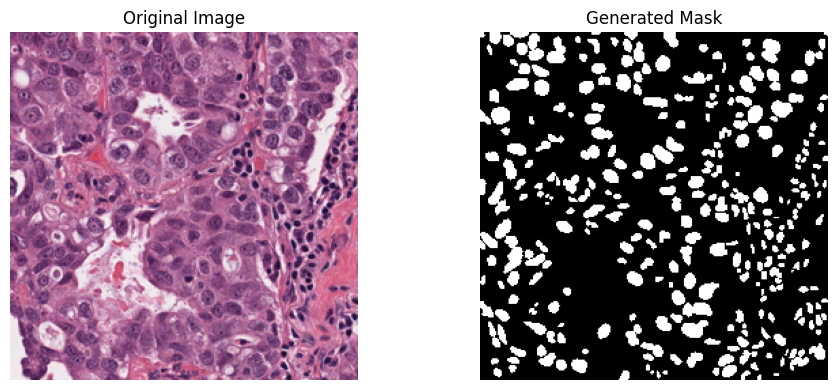

In [14]:
# 전체 시각화 크기 설정
plt.figure(figsize=(10, 4))


# 원본 이미지 출력
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

# 생성된 마스크 이미지 출력
plt.subplot(1, 2, 2)
plt.title("Generated Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

# 자동 레이아웃 정리
plt.tight_layout()
# 시각화 출력
plt.show()

# 모델 구축

## 파라미터 설정

딥러닝시 필요한 파라미터를 설정합니다.<br>
컴퓨터 성능에 알맞게 조절 할 수 있습니다. <br>

In [15]:
IMG_SIZE = 256
BATCH_SIZE = 4
NUM_EPOCHS = 100
NUM_CLASSES = 2
LEARNING_RATE = 1e-3
SAVE_PATH = "trained_model.pth"

## 필요한 모듈 로드

이 셀에서는 모델 구현, 데이터 처리, 시각화 및 파일 입출력에 필요한 주요 모듈들을 한 번에 불러옵니다.<br>
PyTorch 기반 모델 학습을 위한 모듈 외에도, MoNuSeg 데이터셋 전처리에 필요한 XML 파싱, 이미지 처리 모듈도 함께 포함됩니다.

In [16]:
# PyTorch: 모델, 손실 함수, 옵티마이저, 데이터 로딩 관련 모듈
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Torchvision: 데이터 증강 및 텐서 변환 관련 유틸리티
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

# 기타 모듈
import os
from glob import glob
from PIL import Image
import numpy as np
import random
from tqdm import tqdm

## 데이터셋 로드

`커스텀 Dataset 클래스 정의`

In [17]:
class NucleiDataset(Dataset):# PyTorch의 Dataset 클래스를 상속받아 커스텀 데이터셋 정의
    def __init__(self, img_paths, mask_paths, transform=None): # 이미지,마스크 파일 경로 리스트 저장
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self): # 전체 샘플 개수 반환
        return len(self.img_paths)

    def __getitem__(self, idx): # 이미지,마스크 불러와 각각 RGB,흑백으로 변환 후 리사이즈
        img = Image.open(self.img_paths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        mask = Image.open(self.mask_paths[idx]).convert("L").resize((IMG_SIZE, IMG_SIZE))

        if self.transform: # transform이 지정되어 있으면 이미지와 마스크에 적용 
            img = self.transform(img)
            mask = self.transform(mask)

        img = TF.to_tensor(img) # 이미지를 [0,1] 범위의 텐서로 변환 (C, H, W 형태)
        # 마스크를 넘파이 배열로 변환 후 정수 텐서로 변환 (0과 1로 이진화)
        mask = torch.from_numpy(np.array(mask)).long() // 255
        return img, mask

`MoNuSeg 데이터셋 경로 및 파일 리스트 추출`

In [18]:
data_root = "/home/elicer/MoNuSegTrainingData"
img_dir = os.path.join(data_root, "Tissue Images")
xml_dir = os.path.join(data_root, "Annotations")

image_files = sorted(glob(f"{img_dir}/*.tif"))
xml_files = sorted(glob(f"{xml_dir}/*.xml"))

`전처리된 파일 저장 디렉토리 생성`

In [19]:
os.makedirs("train/img", exist_ok=True)
os.makedirs("train/labelcol", exist_ok=True)
os.makedirs("validation/img", exist_ok=True)
os.makedirs("validation/labelcol", exist_ok=True)

`XML → 마스크 생성 함수 정의`

In [20]:
from xml.dom import minidom
from PIL import ImageDraw
# XML → 마스크 변환 함수
def generate_mask_from_xml(xml_path, shape=(1000, 1000)):
    doc = minidom.parse(xml_path)
    regions = doc.getElementsByTagName("Region")
    img = Image.new("L", shape, 0)
    for region in regions:
        vertices = region.getElementsByTagName("Vertex")
        polygon = [(float(v.getAttribute("X")), float(v.getAttribute("Y"))) for v in vertices]
        ImageDraw.Draw(img).polygon(polygon, outline=1, fill=1)
    return np.array(img)

`학습 / 검증 데이터 분할`

In [21]:
# train/val 분할
from sklearn.model_selection import train_test_split
train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42)

`데이터 전처리 루프 정의 및 실행`

In [22]:
# 전처리 루프
def process_dataset(subset, img_list):
    for img_path in tqdm(img_list, desc=f"Processing {subset}"):
        basename = os.path.splitext(os.path.basename(img_path))[0]
        xml_path = os.path.join(xml_dir, f"{basename}.xml")
        if not os.path.exists(xml_path):
            continue

        img = Image.open(img_path).convert("RGB").resize((256, 256))
        img.save(f"{subset}/img/{basename}.png")

        mask = generate_mask_from_xml(xml_path) * 255
        mask = Image.fromarray(mask.astype(np.uint8)).resize((256, 256))
        mask.save(f"{subset}/labelcol/{basename}.png")

process_dataset("train", train_imgs)
process_dataset("validation", val_imgs)

Processing validation: 100%|██████████| 6/6 [00:17<00:00,  2.96s/it]


`전처리된 데이터 수량 확인`

In [23]:
print("Train imgs:", len(glob("train/img/*.png")))
print("Train masks:", len(glob("train/labelcol/*.png")))
print("Val imgs:", len(glob("validation/img/*.png")))
print("Val masks:", len(glob("validation/labelcol/*.png")))

Train imgs: 24
Train masks: 24
Val imgs: 6
Val masks: 6


## 데이터셋 분할

- 앞서 만든 `train/img/*.png`, `train/labelcol/*.png` 등을 리스트로 정렬해서 매칭
- NucleiDataset 객체 생성
- DataLoader로 감싸기

In [24]:
train_img_paths = sorted(glob("train/img/*.png"))
train_mask_paths = sorted(glob("train/labelcol/*.png"))
val_img_paths = sorted(glob("validation/img/*.png"))
val_mask_paths = sorted(glob("validation/labelcol/*.png"))

train_dataset = NucleiDataset(train_img_paths, train_mask_paths)
val_dataset = NucleiDataset(val_img_paths, val_mask_paths)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

## 데이터셋 분할 결과 확인

In [25]:
sample_x, sample_y = next(iter(train_loader))
print("입력 이미지 shape:", sample_x.shape)
print("정답 마스크 shape:", sample_y.shape)

입력 이미지 shape: torch.Size([4, 3, 256, 256])
정답 마스크 shape: torch.Size([4, 256, 256])


/tmp/ipykernel_420/1069639059.py:20: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  mask = torch.from_numpy(np.array(mask)).long() // 255


## 학습 완료 콜백 함수

- 에포크마다 학습이 끝난 직후 호출되는 함수
- 학습하는 동안 가장 적합한 결과물의 가중치를 저장하기 위해 사용

In [26]:
import copy
class BestModelSaver:
    def __init__(self):
        self.best_loss = float("inf")
        self.best_model = None

    def update(self, model, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            print(f" Best model updated (val_loss={val_loss:.4f})")

    def save(self, path):
        torch.save(self.best_model, path)

## 모델 1회 학습
- 하나의 에포크 동안 모델을 학습시키는 루틴을 정의
- 모델을 학습 모드로 설정
- 입력 이미지와 정답 마스크를 GPU로 이동
- 순전파(forward) 및 손실 계산
- 역전파(backward) 및 가중치 갱신
- 전체 손실을 누적하여 평균 손실 반환

In [27]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.cuda(), y.cuda()
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

## 모델 검증
- 에포크가 끝날 때마다 검증 세트에 대해 호출되며,학습 중 모델이 얼마나 일반화되고 있는지를 수치적으로 평가
- model.eval() 모드로 설정하여 Dropout이나 BatchNorm 계층이 비활성화
- torch.no_grad()를 사용하여 gradient 계산을 생략함으로써 메모리 사용량과 연산 속도를 줄임
- 실제 예측은 하되, 역전파(backpropagation)는 미수행

In [28]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.cuda(), y.cuda()
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
    return total_loss / len(loader)

## MedT 구현
- 논문의 제안에 따라 Medical Transformer를 구현
- `qkv_transform` 클래스 : 1D 컨볼루션을 이용해 입력 특징 맵에서 query, key, value를 동시에 추출


In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Axial Attention 구현을 위한 qkv_transform
class qkv_transform(nn.Conv1d):
    """1D Convolution for qkv_transform"""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=False):
        super(qkv_transform, self).__init__(in_channels, out_channels, kernel_size, stride, padding, bias=bias)


`Axial Attention` 메커니즘 구현
- 2D 특징 맵을 축 방향(높이, 너비)으로 분해하여 처리    
- 입력을 1차원으로 변환한 후 어텐션 연산 수행    

주요 기능  
- 입력 변환 : 특징을 `query, key, value`로 변환    
- `Self-attention` : query와 key 간의 유사도 계산    
- 출력 생성 : 유사도와 value를 결합하여 새로운 특징 생성


In [30]:
# Axial Attention 구현
class AxialAttention_wopos(nn.Module):
    def __init__(self, in_planes, out_planes, groups=8, kernel_size=56, stride=1, bias=False, width=False):
        super(AxialAttention_wopos, self).__init__()
        self.in_planes = in_planes               # 입력 채널 수
        self.out_planes = out_planes             # 출력 채널 수
        self.groups = groups                     # 어텐션 헤드 수
        self.group_planes = out_planes // groups # 헤드 당 채널 수
        self.kernel_size = kernel_size           # 커널 사이즈
        self.stride = stride                     # 다운샘플링 비율
        self.bias = bias                         # 바이어스 사용 여부
        self.width = width                       # 너비 방향 어텐션 여부

        # Multi-head self attention 구성 요소
        self.qkv_transform = qkv_transform(in_planes, out_planes * 2, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn_qkv = nn.BatchNorm1d(out_planes * 2)
        self.bn_similarity = nn.BatchNorm2d(groups)
        self.bn_output = nn.BatchNorm1d(out_planes * 1)

        if stride > 1:
            self.pooling = nn.AvgPool2d(stride, stride=stride)

    def forward(self, x):
        # 축 방향에 따른 텐서 변환
        if self.width:
            x = x.permute(0, 2, 1, 3)  # 너비 방향 어텐션
        else:
            x = x.permute(0, 3, 1, 2)  # 높이 방향 어텐션
        N, W, C, H = x.shape
        x = x.contiguous().view(N * W, C, H)

        # Q,K,V 변환
        qkv = self.bn_qkv(self.qkv_transform(x))
        q, k, v = torch.split(qkv.reshape(N * W, self.groups, self.group_planes * 2, H), 
                             [self.group_planes // 2, self.group_planes // 2, self.group_planes], 
                             dim=2)

        # Self-attention
        qk = torch.einsum('bgci, bgcj->bgij', q, k)  # 내적을 사용해 유사도 계산
        qk = self.bn_similarity(qk).reshape(N * W, 1, self.groups, H, H).sum(dim=1).contiguous()
        similarity = F.softmax(qk, dim=3)  # softmax를 통해 어텐션 가중치 생성
        sv = torch.einsum('bgij,bgcj->bgci', similarity, v)  # 가중치와 value 결합

        # 출력 생성 및 정규화
        sv = sv.reshape(N*W, self.out_planes * 1, H).contiguous()
        output = self.bn_output(sv).reshape(N, W, self.out_planes, 1, H).sum(dim=-2).contiguous()

        # 축 방향에 따른 텐서 복원
        if self.width:
            output = output.permute(0, 2, 1, 3)
        else:
            output = output.permute(0, 2, 3, 1)
        
        # 필요시 다운샘플링
        if self.stride > 1:
            output = self.pooling(output)

        return output


`AxialAttention_dynamic` 클래스
- 게이팅 메커니즘이 추가된 Axial Attention    
- 논문의 핵심 기여 중 하나    
- 위치 임베딩과 게이팅 팩터를 사용하여 어텐션 메커니즘 제어       

- Position embedding : 상대적 위치 정보 학습    
- Gating factors : 각 어텐션 컴포넌트에 가중치 적용(f_qr, f_kr, f_sv, f_sve)

In [31]:
class AxialAttention_dynamic(nn.Module):
    def __init__(self, in_planes, out_planes, groups=8, kernel_size=56, stride=1, bias=False, width=False):
        super(AxialAttention_dynamic, self).__init__()
        self.in_planes = in_planes
        self.out_planes = out_planes
        self.groups = groups
        self.group_planes = out_planes // groups
        self.kernel_size = kernel_size
        self.stride = stride
        self.bias = bias
        self.width = width

        # Multi-head self attention 구성 요소
        self.qkv_transform = qkv_transform(in_planes, out_planes * 2, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn_qkv = nn.BatchNorm1d(out_planes * 2)
        self.bn_similarity = nn.BatchNorm2d(groups * 3)
        self.bn_output = nn.BatchNorm1d(out_planes * 2)

        # 게이팅 메커니즘 - 각 어텐션 컴포넌트에 가중치를 적용
        self.f_qr = nn.Parameter(torch.tensor(0.1), requires_grad=False) 
        self.f_kr = nn.Parameter(torch.tensor(0.1), requires_grad=False)
        self.f_sve = nn.Parameter(torch.tensor(0.1), requires_grad=False)
        self.f_sv = nn.Parameter(torch.tensor(1.0), requires_grad=False)

        # Position embedding
        self.relative = nn.Parameter(torch.randn(self.group_planes * 2, kernel_size * 2 - 1), requires_grad=True)
        query_index = torch.arange(kernel_size).unsqueeze(0)
        key_index = torch.arange(kernel_size).unsqueeze(1)
        relative_index = key_index - query_index + kernel_size - 1
        self.register_buffer('flatten_index', relative_index.view(-1))
        if stride > 1:
            self.pooling = nn.AvgPool2d(stride, stride=stride)

    def forward(self, x):
        # 축 방향에 따른 텐서 변환
        if self.width:
            x = x.permute(0, 2, 1, 3)
        else:
            x = x.permute(0, 3, 1, 2)  # N, W, C, H
        N, W, C, H = x.shape
        x = x.contiguous().view(N * W, C, H)

        # Q, K, V 변환
        qkv = self.bn_qkv(self.qkv_transform(x))
        q, k, v = torch.split(qkv.reshape(N * W, self.groups, self.group_planes * 2, H), 
                             [self.group_planes // 2, self.group_planes // 2, self.group_planes], 
                             dim=2)

        # 위치 임베딩 계산
        all_embeddings = torch.index_select(self.relative, 1, self.flatten_index).view(self.group_planes * 2, self.kernel_size, self.kernel_size)
        q_embedding, k_embedding, v_embedding = torch.split(all_embeddings, [self.group_planes // 2, self.group_planes // 2, self.group_planes], dim=0)
        qr = torch.einsum('bgci,cij->bgij', q, q_embedding) 
        kr = torch.einsum('bgci,cij->bgij', k, k_embedding).transpose(2, 3)
        qk = torch.einsum('bgci, bgcj->bgij', q, k)

        # 게이팅 팩터 적용
        qr = torch.mul(qr, self.f_qr)
        kr = torch.mul(kr, self.f_kr)

        # 유사도 계산 및 정규화
        stacked_similarity = torch.cat([qk, qr, kr], dim=1)
        stacked_similarity = self.bn_similarity(stacked_similarity).view(N * W, 3, self.groups, H, H).sum(dim=1)
        similarity = F.softmax(stacked_similarity, dim=3)
        
        # 가중치 출력 계산
        sv = torch.einsum('bgij,bgcj->bgci', similarity, v)
        sve = torch.einsum('bgij,cij->bgci', similarity, v_embedding)

        # 게이팅 팩터 적용
        sv = torch.mul(sv, self.f_sv)
        sve = torch.mul(sve, self.f_sve)

        # 출력 결합 및 정규화
        stacked_output = torch.cat([sv, sve], dim=-1).view(N * W, self.out_planes * 2, H)
        output = self.bn_output(stacked_output).view(N, W, self.out_planes, 2, H).sum(dim=-2)

        if self.width:
            output = output.permute(0, 2, 1, 3)
        else:
            output = output.permute(0, 2, 3, 1)

        if self.stride > 1:
            output = self.pooling(output)

        return output


`AxialBlock_dynamic`
- ResNet 스타일의 잔차 연결 사용
- 높이 방향과 너비 방향의 Axial Attention 순차적 적용        

- Projection: 입력 채널 축소    
- Height-wise attention: 높이 방향 어텐션    
- Width-wise attention: 너비 방향 어텐션    
- Expansion: 채널 확장    
- Skip connection: 잔차 연결로 그래디언트 흐름 개선

In [32]:

# Gated Axial Attention을 사용한 네트워크 블록
class AxialBlock_dynamic(nn.Module):
    expansion = 2  # 채널 확장 비율

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None, kernel_size=56):
        super(AxialBlock_dynamic, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.))  # 특징 맵 너비
        
        # 네트워크 레이어 구성
        self.conv_down = nn.Conv2d(inplanes, width, kernel_size=1, stride=1, bias=False) # 채널 축소
        self.bn1 = norm_layer(width)
        self.hight_block = AxialAttention_dynamic(width, width, groups=groups, kernel_size=kernel_size) # 높이 방향 어텐션
        self.width_block = AxialAttention_dynamic(width, width, groups=groups, kernel_size=kernel_size, stride=stride, width=True)
        self.conv_up = nn.Conv2d(width, planes * self.expansion, kernel_size=1, stride=1, bias=False) # 채널 확장
        self.bn2 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        # 채널 축소, 정규화
        out = self.conv_down(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # 높이 및 너비 방향 어텐션 적용
        out = self.hight_block(out)
        out = self.width_block(out)
        out = self.relu(out)

        # 채널 확장, 정규화
        out = self.conv_up(out)
        out = self.bn2(out)

        # 잔차 경로 처리
        if self.downsample is not None:
            identity = self.downsample(x)

        # 잔차 연결 및 활성화
        out += identity
        out = self.relu(out)

        return out


`Medical Transformer` 클래스
- 글로벌 경로 (Global Path): 전체 이미지를 처리하는 인코더-디코더 구조, 넓은 영역의 문맥 정보 캡처        

- 로컬 경로 (Local Path) : 이미지를 패치로 분할하여 독립적으로 처리, 지역적 세부 정보와 경계를 더 정확히 포착   

-LoGo 융합을 통한 로컬 및 글로벌 특징 결합으로 세분화 성능 향상과 의료 영상의 복잡한 구조와 텍스처 효과적 처리


In [33]:
class MedT(nn.Module):
    def __init__(self, in_channels=3, num_classes=2, img_size=256, s=0.125):
        super(MedT, self).__init__()
        self.inplanes = int(64 * s)
        self.groups = 8
        self.base_width = 64
        norm_layer = nn.BatchNorm2d
        
        # Main branch (Global 처리)
        self.conv1 = nn.Conv2d(in_channels, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.conv2 = nn.Conv2d(self.inplanes, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = norm_layer(128)
        self.conv3 = nn.Conv2d(128, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        
        # Global branch encoder
        self.layer1 = self._make_layer(AxialBlock_dynamic, int(128 * s), layers=1, kernel_size=img_size//2)
        self.layer2 = self._make_layer(AxialBlock_dynamic, int(256 * s), layers=1, stride=2, kernel_size=img_size//2)
        
        # Global branch decoder
        self.decoder4 = nn.Conv2d(int(512 * s), int(256 * s), kernel_size=3, stride=1, padding=1)
        self.decoder5 = nn.Conv2d(int(256 * s), int(128 * s), kernel_size=3, stride=1, padding=1)
        
        # Local branch (패치 단위 처리)
        self.conv1_p = nn.Conv2d(in_channels, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1_p = norm_layer(self.inplanes)
        self.conv2_p = nn.Conv2d(self.inplanes, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_p = norm_layer(128)
        self.conv3_p = nn.Conv2d(128, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_p = norm_layer(self.inplanes)
        
        # Patch-wise encoder
        img_size_p = img_size // 4
        self.layer1_p = self._make_layer(AxialBlock_dynamic, int(128 * s), layers=1, kernel_size=img_size_p//2)
        self.layer2_p = self._make_layer(AxialBlock_dynamic, int(256 * s), layers=1, stride=2, kernel_size=img_size_p//2)
        self.layer3_p = self._make_layer(AxialBlock_dynamic, int(512 * s), layers=1, stride=2, kernel_size=img_size_p//4)
        self.layer4_p = self._make_layer(AxialBlock_dynamic, int(1024 * s), layers=1, stride=2, kernel_size=img_size_p//8)
        
        # Patch-wise decoder
        self.decoder1_p = nn.Conv2d(int(1024 * 2 * s), int(1024 * 2 * s), kernel_size=3, stride=1, padding=1)
        self.decoder2_p = nn.Conv2d(int(1024 * 2 * s), int(1024 * s), kernel_size=3, stride=1, padding=1)
        self.decoder3_p = nn.Conv2d(int(1024 * s), int(512 * s), kernel_size=3, stride=1, padding=1)
        self.decoder4_p = nn.Conv2d(int(512 * s), int(256 * s), kernel_size=3, stride=1, padding=1)
        self.decoder5_p = nn.Conv2d(int(256 * s), int(128 * s), kernel_size=3, stride=1, padding=1)
        
        # Final layers
        self.decoderf = nn.Conv2d(int(128 * s), int(128 * s), kernel_size=3, stride=1, padding=1)
        self.adjust = nn.Conv2d(int(128 * s), num_classes, kernel_size=1, stride=1, padding=0)
        
    def _make_layer(self, block, planes, layers, kernel_size=56, stride=1, dilate=False):
        norm_layer = nn.BatchNorm2d
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                norm_layer(planes * block.expansion),
            )

        layer_blocks = []
        layer_blocks.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, norm_layer=norm_layer, kernel_size=kernel_size))
        self.inplanes = planes * block.expansion
        
        for _ in range(1, layers):
            layer_blocks.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, norm_layer=norm_layer, 
                                kernel_size=kernel_size))

        return nn.Sequential(*layer_blocks)
    
    def forward(self, x):
        # 원본 입력 저장
        xin = x.clone()
        B, C, H, W = x.shape  # 원본 이미지 크기
        
        # Global branch
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        
        # 전체 이미지 디코더
        x = F.relu(F.interpolate(self.decoder4(x2), size=x1.shape[2:], mode='bilinear', align_corners=False))
        x = torch.add(x, x1)
        x = F.relu(F.interpolate(self.decoder5(x), scale_factor=2, mode='bilinear', align_corners=False))
        
        # Local branch - LoGo 전략 구현
        x_loc = x.clone()  # 전역 특징 복사
        _, C_loc, H_loc, W_loc = x_loc.shape  # 특징 맵 크기
        
        # 패치 수와 크기 계산
        n_patches = 4  # 4x4 패치 그리드
        patch_size_h = H // n_patches
        patch_size_w = W // n_patches
        
        # 특징 맵에서의 패치 크기
        feat_patch_h = H_loc // n_patches
        feat_patch_w = W_loc // n_patches
        
        # 패치 단위로 처리
        for i in range(n_patches):
            for j in range(n_patches):
                # 패치 추출 (원본 이미지에서)
                x_p = xin[:, :, i*patch_size_h:(i+1)*patch_size_h, j*patch_size_w:(j+1)*patch_size_w]
                
                # 패치 인코더
                x_p = self.conv1_p(x_p)
                x_p = self.bn1_p(x_p)
                x_p = self.relu(x_p)
                x_p = self.conv2_p(x_p)
                x_p = self.bn2_p(x_p)
                x_p = self.relu(x_p)
                x_p = self.conv3_p(x_p)
                x_p = self.bn3_p(x_p)
                x_p = self.relu(x_p)
                
                x1_p = self.layer1_p(x_p)
                x2_p = self.layer2_p(x1_p)
                x3_p = self.layer3_p(x2_p)
                x4_p = self.layer4_p(x3_p)
                
                # 패치 디코더 - 업샘플링과 스킵 커넥션을 위한 크기 조정
                # 역방향 크기를 명시적으로 계산
                x4_p_up = F.interpolate(self.decoder1_p(x4_p), size=x4_p.shape[2:], mode='bilinear', align_corners=False)
                x_p = F.relu(torch.add(x4_p_up, x4_p))
                
                x3_p_up = F.interpolate(self.decoder2_p(x_p), size=x3_p.shape[2:], mode='bilinear', align_corners=False)
                x_p = F.relu(torch.add(x3_p_up, x3_p))
                
                x2_p_up = F.interpolate(self.decoder3_p(x_p), size=x2_p.shape[2:], mode='bilinear', align_corners=False)
                x_p = F.relu(torch.add(x2_p_up, x2_p))
                
                x1_p_up = F.interpolate(self.decoder4_p(x_p), size=x1_p.shape[2:], mode='bilinear', align_corners=False)
                x_p = F.relu(torch.add(x1_p_up, x1_p))
                
                # 최종 업샘플링 및 특징 맵 크기로 조정
                x_p = F.relu(F.interpolate(self.decoder5_p(x_p), size=(feat_patch_h, feat_patch_w), mode='bilinear', align_corners=False))
                
                # 패치 결과를 특징 맵에 결합
                x_loc[:, :, i*feat_patch_h:(i+1)*feat_patch_h, j*feat_patch_w:(j+1)*feat_patch_w] = x_p
        
        # 전역 및 지역 특징 결합
        x = torch.add(x, x_loc)
        x = F.relu(self.decoderf(x))
        
        # 최종 예측
        x = self.adjust(x)
        
        return x

In [34]:
# 모델 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MedT(in_channels=3, num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
best_saver = BestModelSaver()

# 학습 루프
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)
    best_saver.update(model, val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

best_saver.save(SAVE_PATH)

/tmp/ipykernel_420/1069639059.py:20: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  mask = torch.from_numpy(np.array(mask)).long() // 255


 Best model updated (val_loss=0.4544)
Epoch 1/100 | Train Loss: 0.4812 | Val Loss: 0.4544
 Best model updated (val_loss=0.4369)
Epoch 2/100 | Train Loss: 0.4058 | Val Loss: 0.4369
 Best model updated (val_loss=0.4084)
Epoch 3/100 | Train Loss: 0.3608 | Val Loss: 0.4084
 Best model updated (val_loss=0.3925)
Epoch 4/100 | Train Loss: 0.3321 | Val Loss: 0.3925
 Best model updated (val_loss=0.3749)
Epoch 5/100 | Train Loss: 0.3081 | Val Loss: 0.3749
 Best model updated (val_loss=0.3597)
Epoch 6/100 | Train Loss: 0.2947 | Val Loss: 0.3597
 Best model updated (val_loss=0.3296)
Epoch 7/100 | Train Loss: 0.2997 | Val Loss: 0.3296
 Best model updated (val_loss=0.3141)
Epoch 8/100 | Train Loss: 0.3102 | Val Loss: 0.3141
Epoch 9/100 | Train Loss: 0.2757 | Val Loss: 0.3296
 Best model updated (val_loss=0.3097)
Epoch 10/100 | Train Loss: 0.2710 | Val Loss: 0.3097
 Best model updated (val_loss=0.2894)
Epoch 11/100 | Train Loss: 0.2706 | Val Loss: 0.2894
Epoch 12/100 | Train Loss: 0.2687 | Val Loss: 

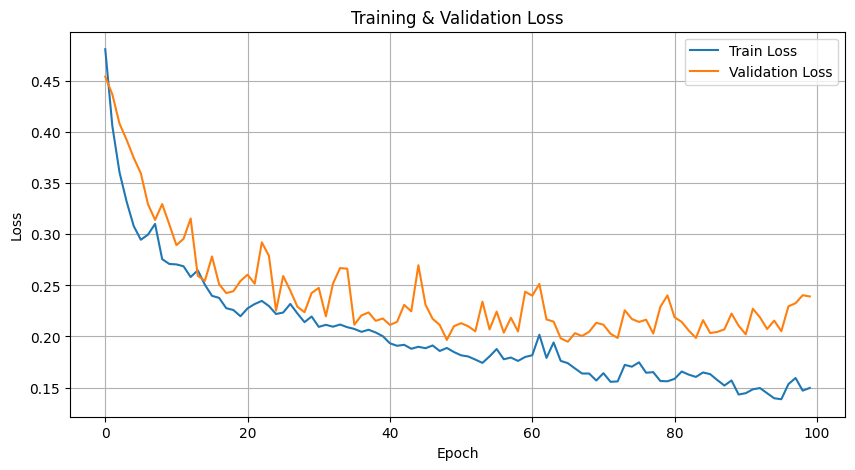

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 결론 시각화
-  학습이 완료된 모델을 이용해 테스트 이미지에 대한 세그멘테이션 예측 결과를 생성

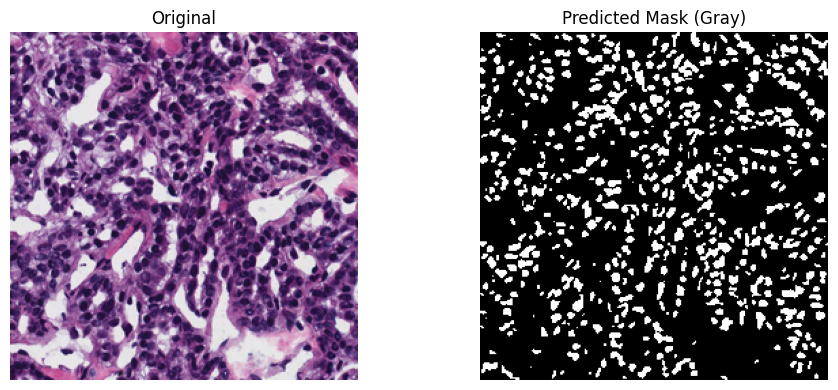

In [36]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 추론용 이미지 경로
test_img_path = "MoNuSegTestData/TCGA-2Z-A9J9-01A-01-TS1.tif"

# 이미지 전처리
test_img = Image.open(test_img_path).convert("RGB").resize((256, 256))
input_tensor = TF.to_tensor(test_img).unsqueeze(0).to(device)  # BxCxHxW

# 모델 추론
model.eval()
with torch.no_grad():
    output = model(input_tensor)  # (1, 2, 256, 256)
    pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()  # (256, 256)

# 시각화 (overlay)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(test_img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Predicted Mask (Gray)")
plt.imshow(pred, cmap="gray")


plt.axis("off")

plt.tight_layout()
plt.show()


# 결론
- 논문은 Transformer의 장점을 의료 영상 분할에 도입하기 위해 `Gated Axial-Attention`과 `Local-Global(LoGo)` 학습 전략을 제안

- `Gated Axial-Attention`은 상대 위치 정보의 중요도를 학습 가능한 게이트로 조절함으로써, 작은 의료 데이터셋에서도 효과적인 학습이 가능

- `LoGo 학습`은 전체 이미지를 처리하는 `Global branch`와 국소 정보를 집중적으로 처리하는 `Local branch`의 두 가지 경로를 사용해 성능을 높임

- 논문은 세 개의 의료 영상 데이터셋(Brain US, GlaS, MoNuSeg)에 대해 실험을 수행하였고, 제안된 MedT(Medical Transformer) 모델이 기존 `CNN` 및 `Transformer` 기반 모델 대비 향상된 성능을 달성함을 보임. 

- `Transformer` 기반 구조임에도 불구하고, `사전학습(pretraining) `없이도 우수한 성능을 보임.

## 주요 업적
- `Gated Axial Attention` 구조 제안 : 상대 위치 인코딩의 유효성을 학습 가능한 게이트를 통해 조절하는 새로운 `self-attention` 구조를 도입

- `Local-Global(LoGo)` 학습 전략 제안 : 전체 이미지와 패치를 병행하여 학습함으로써, 전역 정보와 세부 정보를 동시에 학습하도록 설계

- 사전학습 없이도 효과적인 `Transformer` 구조 : 기존 ViT 기반 모델들이 대규모 사전학습을 요구하는 반면, MedT는 소규모 의료 데이터셋에서도 경쟁력 있는 성능을 발휘

- 정량적 성능 향상 : `F1 Score` 기준, Brain US, GlaS, MoNuSeg 세 데이터셋 모두에서 기존 CNN 및 Transformer 구조보다 높은 성능을 기록


## 현장 실무에 유용할 주요 핵심 정리

- `Transformer` 기반 의료 영상 모델이 반드시 대규모 데이터가 필요한 것은 아니라는 것을 증명

- `Global + Local` 병렬 학습 전략을 통해 다양한 해상도에서 발생할 수 있는` segmentation` 오류를 줄일 수 있음.

- 비교적 적은 파라미터 수로도 높은 정확도를 확보할 수 있어, 임베디드 시스템이나 제한된 자원 환경에서도 사용 가능

- 코드 구조가 비교적 단순해 재현성과 확장성이 높으며, 실제 병원 시스템에 통합 가능성도 존재


## 기술적 한계

- 로컬-글로벌(Local-Global, LoGo) 전략의 구성 복잡성
- MedT는 두 개의 분기(global, local)로 구성되며, 이로 인해 모델 구조가 다소 복잡해짐.
- global branch의 레이어 수를 제한해야만 파라미터 수를 억제할 수 있었음.

## 향후 연구 과제
- MedT는 `사전학습` 없이도 소규모 데이터셋에서 잘 작동하는 구조를 제안하였으나, 이와 같은 접근이 다양한 의료 영역에 일반화 가능한지 추가 연구 필요

- 다양한 데이터셋과 병변 종류에 대한 적용성 검증 필요

- `Gated Axial Attention`은 `포지셔널 인코딩`의 신뢰도에 따라 게이트가 정보를 조절하지만, 게이트의 동작에 대한 정량적 분석과 최적화는 향후 연구 필요
